In [1]:
import numpy as np
import pandas as pd
from datasets import load_dataset

In [2]:
ds = load_dataset("mshenoda/spam-messages", encoding='latin-1')

In [3]:
train_df = ds['train'].to_pandas()
valid_df = ds['validation'].to_pandas()
test_df = ds['test'].to_pandas()

df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

In [4]:
df.shape

(59241, 2)

In [5]:
df.sample(5)

,label,text
45860,spam,"to whom it may concern , online pharmacy medic..."
17381,spam,people who rech with world cup top up got free...
24164,ham,i am working on clearing an old txu lone star ...
16876,spam,win a hong kong trip only at blue hyundai duri...
50528,spam,click here to be removed


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59241 entries, 0 to 59240
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   59241 non-null  str  
 1   text    59241 non-null  str  
dtypes: str(2)
memory usage: 55.6 MB


In [7]:
df.rename(columns={'label':'target'}, inplace=True)

In [8]:
df.sample(5)

,target,text
57243,spam,canadian business publications 4865 hwy . 138 ...
13530,ham,i thot d date tl nw would hve been a bit more ...
4230,ham,"Night night, see you tomorrow"
41443,spam,investor alert - l r c j - brand new stock for...
50646,ham,"hey leaders , ? as you know there will be a co..."


In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [10]:
df['target'] = encoder.fit_transform(df['target'])

In [11]:
df.head()

,target,text
0,0,"Funny fact Nobody teaches volcanoes 2 erupt, t..."
1,0,I sent my scores to sophas and i had to do sec...
2,1,We know someone who you know that fancies you....
3,0,Only if you promise your getting out as SOON a...
4,1,Congratulations ur awarded either ï¿½500 of CD...


In [12]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(4278)

In [14]:
df = df.drop_duplicates(keep='first')

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(54963, 2)

# EDA

In [17]:
df.head()

,target,text
0,0,"Funny fact Nobody teaches volcanoes 2 erupt, t..."
1,0,I sent my scores to sophas and i had to do sec...
2,1,We know someone who you know that fancies you....
3,0,Only if you promise your getting out as SOON a...
4,1,Congratulations ur awarded either ï¿½500 of CD...


In [18]:
df['target'].value_counts()

target
0    34336
1    20627
Name: count, dtype: int64

In [19]:
import matplotlib.pyplot as plt

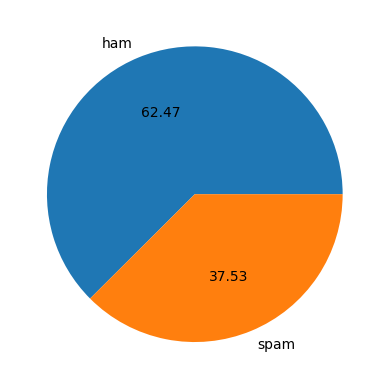

In [20]:
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct='%0.2f')
plt.show()

In [21]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASTHA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASTHA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
df['num_characters'] = df['text'].apply(len)

In [23]:
df.head()

,target,text,num_characters
0,0,"Funny fact Nobody teaches volcanoes 2 erupt, t...",151
1,0,I sent my scores to sophas and i had to do sec...,221
2,1,We know someone who you know that fancies you....,101
3,0,Only if you promise your getting out as SOON a...,124
4,1,Congratulations ur awarded either ï¿½500 of CD...,152


In [24]:
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [25]:
df.head()

,target,text,num_characters,num_words
0,0,"Funny fact Nobody teaches volcanoes 2 erupt, t...",151,28
1,0,I sent my scores to sophas and i had to do sec...,221,47
2,1,We know someone who you know that fancies you....,101,22
3,0,Only if you promise your getting out as SOON a...,124,31
4,1,Congratulations ur awarded either ï¿½500 of CD...,152,23


In [26]:
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [27]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Funny fact Nobody teaches volcanoes 2 erupt, t...",151,28,1
1,0,I sent my scores to sophas and i had to do sec...,221,47,3
2,1,We know someone who you know that fancies you....,101,22,3
3,0,Only if you promise your getting out as SOON a...,124,31,2
4,1,Congratulations ur awarded either ï¿½500 of CD...,152,23,1


In [28]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,54963.000000,54963.000000,54963.000000
mean,915.599294,186.266707,10.537707
std,3128.337931,624.916285,42.536576
min,1.000000,1.000000,1.000000
25%,122.000000,24.000000,1.000000
50%,402.000000,79.000000,3.000000
75%,800.000000,165.000000,10.000000
max,228353.000000,45450.000000,3093.000000


In [29]:
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,34336.000000,34336.000000,34336.000000
mean,868.274260,181.902085,9.248427
std,3736.613466,746.824460,45.068694
min,1.000000,1.000000,1.000000
25%,68.000000,15.000000,1.000000
50%,329.500000,67.000000,2.000000
75%,799.000000,152.000000,8.000000
max,228353.000000,45450.000000,2827.000000


In [30]:
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,20627.000000,20627.000000,20627.000000
mean,994.377224,193.532118,12.683861
std,1681.022593,334.786390,37.852495
min,1.000000,1.000000,1.000000
25%,205.000000,37.000000,1.000000
50%,472.000000,89.000000,5.000000
75%,904.500000,188.000000,13.500000
max,28692.000000,8386.000000,3093.000000


In [31]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

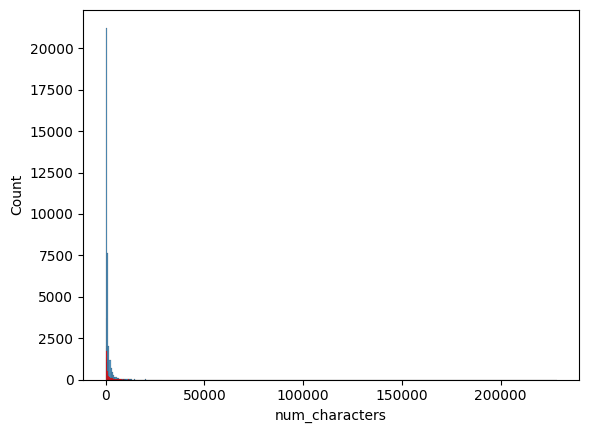

In [32]:
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

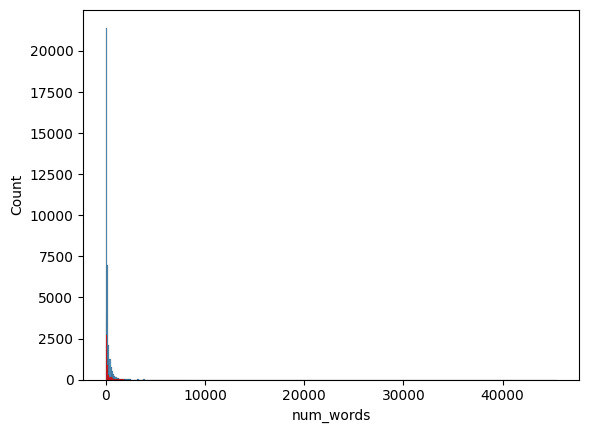

In [33]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'], color='red')

<Axes: xlabel='num_sentences', ylabel='Count'>

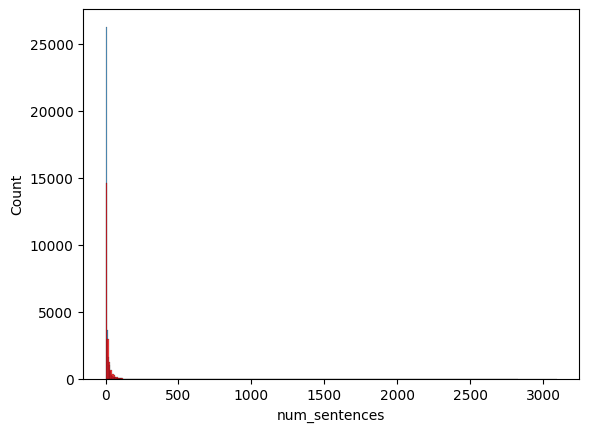

In [34]:
sns.histplot(df[df['target']==0]['num_sentences'])
sns.histplot(df[df['target']==1]['num_sentences'], color='red')

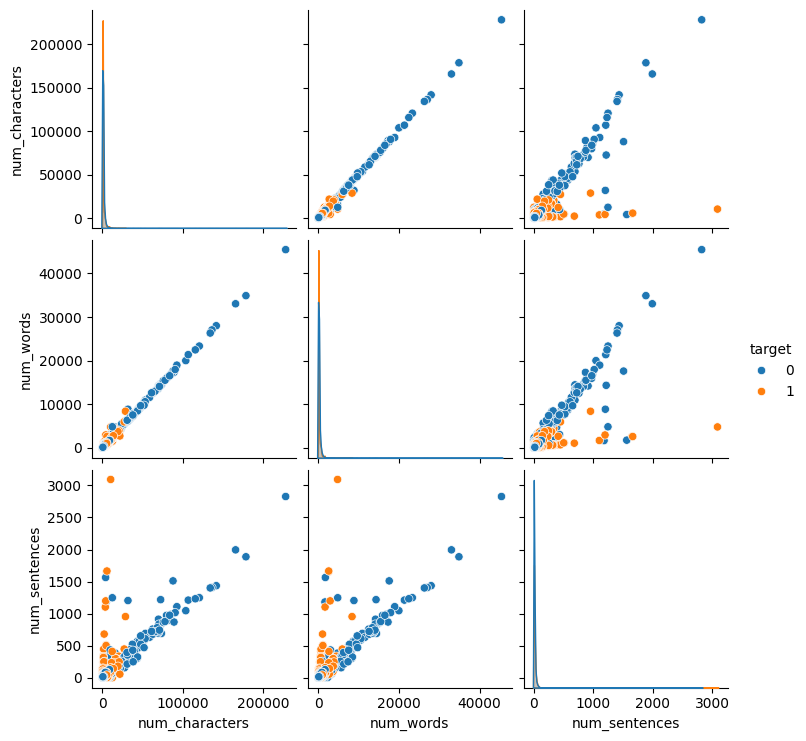

In [35]:
sns.pairplot(df, hue='target')

<Axes: >

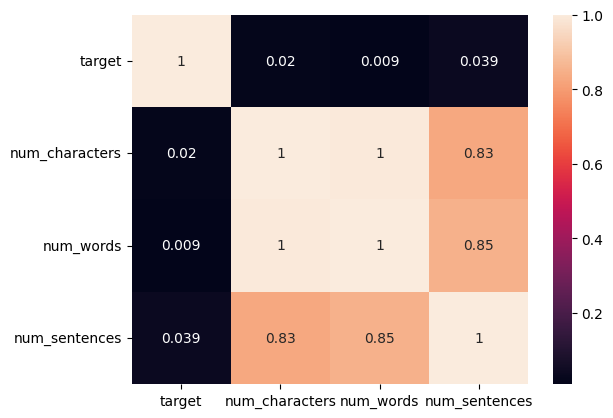

In [36]:
sns.heatmap(df[['target','num_characters','num_words','num_sentences']].corr(), annot=True)

# Data Preprocessing

In [37]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

In [38]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = [i for i in text if i.isalnum()]
    y = [i for i in y if i not in stop_words and i not in string.punctuation]
    y = [ps.stem(i) for i in y]

    return " ".join(y)

In [39]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [40]:
ps.stem("listening")

'listen'

In [41]:
transform_text(df['text'].iloc[0])

'funni fact nobodi teach volcano 2 erupt tsunami 2 aris hurrican 2 sway aroundn 1 teach hw 2 choos wife natur disast happen'

In [42]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Funny fact Nobody teaches volcanoes 2 erupt, t...",151,28,1
1,0,I sent my scores to sophas and i had to do sec...,221,47,3
2,1,We know someone who you know that fancies you....,101,22,3
3,0,Only if you promise your getting out as SOON a...,124,31,2
4,1,Congratulations ur awarded either ï¿½500 of CD...,152,23,1


In [43]:
from wordcloud import WordCloud
wc = WordCloud(width=400, height=400, min_font_size=10, background_color='black')

In [44]:
df.columns

Index(['target', 'text', 'num_characters', 'num_words', 'num_sentences'], dtype='str')

In [45]:
df['transformed_text'] = df['text'].apply(transform_text)

In [46]:
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=' '))

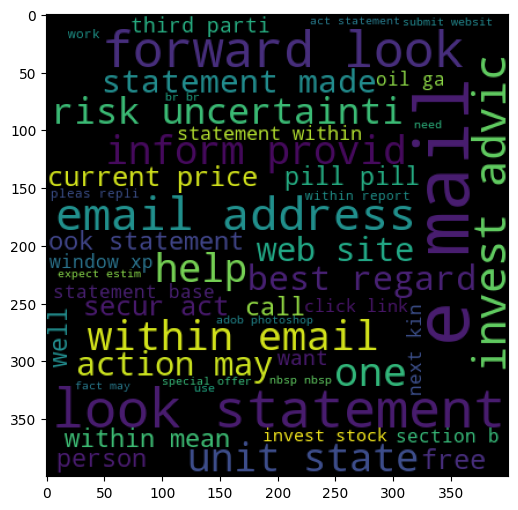

In [47]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [48]:
ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=' '))

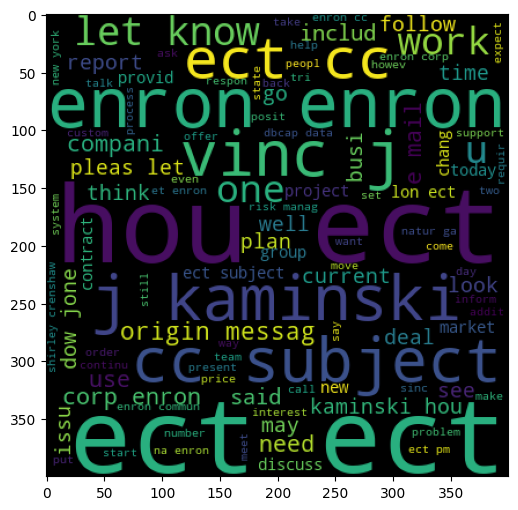

In [49]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [50]:
spam_corpus = []
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [51]:
len(spam_corpus)

2095815

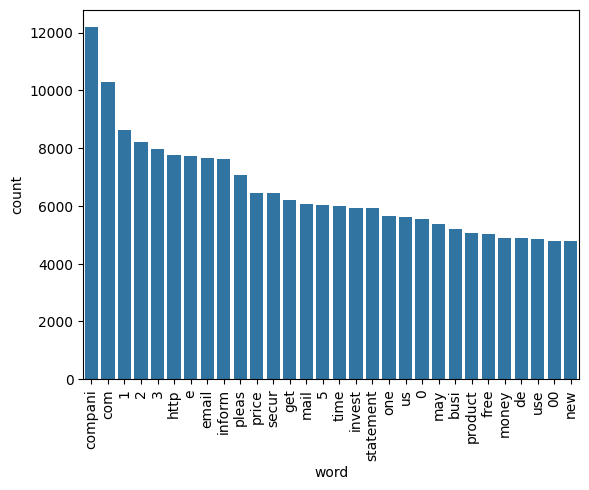

In [52]:
from collections import Counter

common_words = Counter(spam_corpus).most_common(30)
df_counter = pd.DataFrame(common_words, columns=['word','count'])

sns.barplot(data=df_counter, x='word', y='count')
plt.xticks(rotation='vertical')
plt.show()

In [53]:
ham_corpus = []
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [54]:
len(ham_corpus)

3131927

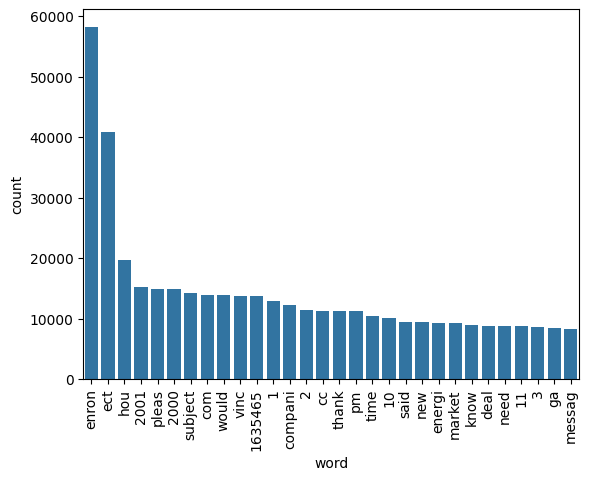

In [55]:
common_words = Counter(ham_corpus).most_common(30)
df_counter = pd.DataFrame(common_words, columns=['word','count'])

sns.barplot(data=df_counter, x='word', y='count')
plt.xticks(rotation='vertical')
plt.show()

# Model

**Change vs. the original version:** `ngram_range=(1,2)` catches short spammy phrases
("call now", "click here") instead of only single words, `sublinear_tf=True` stops
very repetitive spam text ("FREE FREE FREE!!!") from dominating the vector, and
`min_df=2` drops one-off tokens that don't generalize.

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2, max_features=6000)
X = tfidf.fit_transform(df['transformed_text'])
y = df['target'].values
X.shape

(54963, 6000)

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [58]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, f1_score

In [59]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred1 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.9196761575548076
[[6360  507]
 [ 376 3750]]
0.8809020436927414


In [60]:
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.8757391067042664
[[6761  106]
 [1260 2866]]
0.9643337819650067


**Bug fix:** the `xgboost` import below was cut off in the original notebook
(`from xgboost` with no `import XGBClassifier`), which would crash this cell.
Also added `CalibratedClassifierCV` so `LinearSVC` can produce probability scores —
needed later for soft voting and for the confidence bar in the web app.

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, BaggingClassifier,
    ExtraTreesClassifier, GradientBoostingClassifier
)
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV

**Change:** `class_weight='balanced'` added to the linear models — spam datasets
are usually skewed toward ham, and without this the model quietly biases toward
predicting "not spam".

In [62]:
svc = CalibratedClassifierCV(LinearSVC(random_state=42, class_weight='balanced'))
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1', class_weight='balanced')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2, eval_metric='logloss')

In [63]:
clfs = {
    'SVC': svc,
    'KN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
}

In [64]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return accuracy, precision, f1

**Change:** this comparison loop was commented out in the original notebook, so
you never actually got to see which algorithm won — it's live now.

In [65]:
accuracy_scores = []
precision_scores = []
f1_scores = []

for name, clf in clfs.items():
    acc, prec, f1 = train_classifier(clf, X_train, y_train, X_test, y_test)
    print("For", name)
    print("Accuracy -", acc)
    print("Precision -", prec)
    print("F1 -", f1)
    accuracy_scores.append(acc)
    precision_scores.append(prec)
    f1_scores.append(f1)

For SVC
Accuracy - 0.9449649777130902
Precision - 0.9350135903138127
F1 - 0.9259757738896366
For KN
Accuracy - 0.8042390612207768
Precision - 0.771900826446281
F1 - 0.7225373904074265
For NB
Accuracy - 0.9196761575548076
Precision - 0.8809020436927414
F1 - 0.8946677800310151
For DT
Accuracy - 0.7745838260711362
Precision - 0.9199796126401631
F1 - 0.592969776609724


C:\Users\ASTHA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\ASTHA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For LR
Accuracy - 0.9389611570999727
Precision - 0.9125865775017913
F1 - 0.9192830506435703
For RF
Accuracy - 0.9508778313472209
Precision - 0.9541540020263425
F1 - 0.9331186524647015
For AdaBoost
Accuracy - 0.8227053579550623
Precision - 0.8925351604760188
F1 - 0.7174952891723438
For BgC
Accuracy - 0.9391430910579459
Precision - 0.9296544867014666
F1 - 0.9179040373051908
For ETC
Accuracy - 0.9576093877922314
Precision - 0.9635258358662614
F1 - 0.9422838741639832
For GBDT
Accuracy - 0.8468116073865187
Precision - 0.9323654390934845
F1 - 0.7576978417266187
For xgb
Accuracy - 0.9191303556808879
Precision - 0.951968723820162
F1 - 0.8846503178928247


In [66]:
performance_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'F1': f1_scores
}).sort_values('F1', ascending=False)

performance_df

,Algorithm,Accuracy,Precision,F1
8,ETC,0.957609,0.963526,0.942284
5,RF,0.950878,0.954154,0.933119
0,SVC,0.944965,0.935014,0.925976
4,LR,0.938961,0.912587,0.919283
7,BgC,0.939143,0.929654,0.917904
2,NB,0.919676,0.880902,0.894668
10,xgb,0.919130,0.951969,0.884650
9,GBDT,0.846812,0.932365,0.757698
1,KN,0.804239,0.771901,0.722537
6,AdaBoost,0.822705,0.892535,0.717495


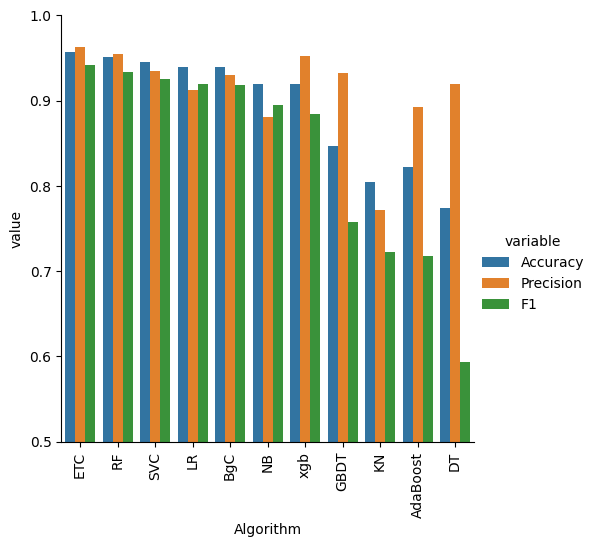

In [67]:
performance_df1 = pd.melt(performance_df, id_vars='Algorithm')

sns.catplot(x='Algorithm', y='value', hue='variable', data=performance_df1, kind='bar', height=5)
plt.ylim(0.5, 1.0)
plt.xticks(rotation='vertical')
plt.show()

# Final model — soft-voting ensemble

**Change:** switched `voting='hard'` to `voting='soft'`. Hard voting only counts
majority votes and can't expose a confidence score. Soft voting averages predicted
probabilities across the three models, which tends to be a bit more accurate *and*
is what lets the web app show a confidence bar.

In [68]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('svm', svc),
        ('nb', mnb),
        ('et', etc)
    ],
    voting='soft'
)

voting.fit(X_train, y_train)
y_pred = voting.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9545165105066861
Precision: 0.9507707608155147
F1       : 0.9386352479135984
[[6669  198]
 [ 302 3824]]


### Optional: stacking classifier
Left here as an alternative worth trying — sometimes beats voting, sometimes doesn't,
depends on the dataset. Uncomment to test.

In [69]:
# from sklearn.ensemble import StackingClassifier
#
# estimators = [('svm', svc), ('nb', mnb), ('et', etc)]
# final_estimator = RandomForestClassifier()
# stack_clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)
# stack_clf.fit(X_train, y_train)
# y_pred = stack_clf.predict(X_test)
# print('Accuracy', accuracy_score(y_test, y_pred))
# print('Precision', precision_score(y_test, y_pred))
# print('F1', f1_score(y_test, y_pred))

### Save for the Flask app
Refit on the *full* dataset (train + test) before saving, so the deployed model
isn't leaving 20% of your data on the table.

In [70]:
voting.fit(X, y)

import pickle
pickle.dump(tfidf, open('vectorizer1.pkl', 'wb'))
pickle.dump(voting, open('model1.pkl', 'wb'))
print("Saved vectorizer1.pkl and model1.pkl")

Saved vectorizer1.pkl and model1.pkl
